In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eloUtils
import gc
import datetime

In [45]:
#Data obtained from this script https://github.com/Nathanlauga/nba-data-scrapping/
games = pd.read_csv('games.csv',nrows=26300)
games_details = pd.read_csv('games_details.csv')
players = pd.read_csv('players.csv')
teams = pd.read_csv('teams.csv')
ranking = pd.read_csv('ranking.csv')
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])




/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_3169/1543253632.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('games_details.csv')


In [7]:
games.tail()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
26295,2003-11-21,20300175,Final,1610612760,1610612763,2003,1610612760,97.0,0.457,0.640,...,21.0,45.0,1610612763,98.0,0.393,0.667,0.455,19.0,41.0,0
26296,2003-11-21,20300164,Final,1610612755,1610612738,2003,1610612755,87.0,0.448,0.889,...,20.0,40.0,1610612738,85.0,0.387,0.778,0.316,16.0,35.0,1
26297,2003-11-20,20300163,Final,1610612756,1610612753,2003,1610612756,96.0,0.513,0.714,...,28.0,34.0,1610612753,89.0,0.419,0.750,0.263,20.0,50.0,1
26298,2003-11-20,20300162,Final,1610612742,1610612759,2003,1610612742,95.0,0.369,0.824,...,18.0,49.0,1610612759,92.0,0.443,0.714,0.143,25.0,47.0,1
26299,2003-11-19,20300155,Final,1610612754,1610612746,2003,1610612754,91.0,0.423,0.885,...,21.0,49.0,1610612746,78.0,0.365,0.767,0.083,13.0,42.0,1


In [8]:
gc.collect()

0

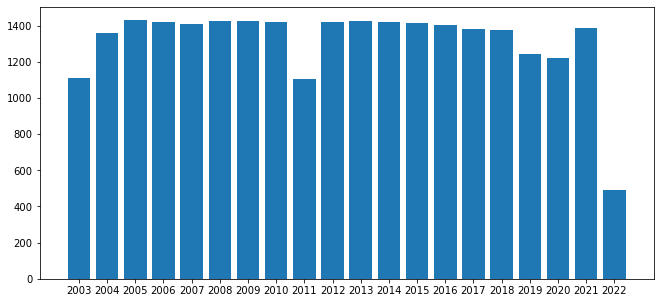

In [9]:
fig, ax = plt.subplots(figsize=(11,5))

v_c = games['SEASON'].value_counts().sort_index()
v_c.index = v_c.index.astype(str)
ax.bar(v_c.index, v_c.values)

plt.show()

In [46]:
def get_avg_stats_last_n_games(team, game_date, season_team_stats, n) :
  prev_game_df = season_team_stats[(season_team_stats['GAME_DATE_EST'] < game_date) & (season_team_stats['TEAM_ID_home'] == team) | (season_team_stats['TEAM_ID_home'] == team)].head(n)
  data = []
  for index,prev_game_row in prev_game_df.iterrows():
    if(prev_game_row['TEAM_ID_home'] == team):
        h_df = prev_game_row[[7,8,9,10,11,12]]
        data.append(h_df.tolist())
    if(prev_game_row['TEAM_ID_away']==team):
            #h_df.columns = [x[2:] for x in h_df.columns]   
        a_df = prev_game_row[[14,15,16,17,18,19]]
        data.append(a_df.tolist())
  ndf = pd.DataFrame(data, columns=['PTS', 'FG_PCT', 'FT_PCT','FG3_PCT','AST','REB'])          

  return ndf.mean()

The eloUtils.py file contains the helper methods to calculate elo and reset each teams ELO after each season. Having the file in the working directory should be fine, which would allow this notebook to find the helper functions. The cell below creates features for each game.

In [47]:
#Code to calculate ELO adapted from this article https://medium.com/mlearning-ai/how-to-calculate-elo-score-for-international-teams-using-python-66c136f01048
# Creating the empty dictionary that is going to store the current elo for each team
import eloUtils
current_elo={}
recentTeamPerformance = {}
games =  games.loc[::-1]
performance_data = []
recent_performance_df = pd.DataFrame()
curr_season = 2003
for idx,row in games.iterrows():
    # Getting the data that it is nedeed to calculate the elo 
    home=row['TEAM_ID_home']
    away=row['TEAM_ID_away']
    home_pts=row['PTS_home']
    away_pts=row['PTS_away']
    game_date = row['GAME_DATE_EST']
    game_id = row['GAME_ID']
    season = row['SEASON']
    
    if season != curr_season:
        curr_season = season
        for key in current_elo.keys():
            final_season_elo = current_elo[key]
            current_elo[key] = eloUtils.soft_reset(final_season_elo)



    # Getting elo before match. If it is the first match played, the elo is initialized in 1500.
    if home not in current_elo.keys():
        current_elo[home]=1500
    
    if away not in current_elo.keys():
        current_elo[away]=1500
    
    #calculating and updating elo
    elo_h=current_elo[home]
    elo_aw=current_elo[away]
    elo_ln,elo_vn=eloUtils.calculate_elo(elo_h,elo_aw,home_pts,away_pts)

    current_elo[home]=elo_ln
    current_elo[away]=elo_vn

    h_team_recent_performance = get_avg_stats_last_n_games(home, game_date, games, 5)
    #h_team_recent_performance.index = ['H_Last_10_Avg_' + x for x in h_team_recent_performance.index]
    recentTeamPerformance[home]=h_team_recent_performance.tolist()


    a_team_recent_performance = get_avg_stats_last_n_games(away, game_date, games, 5)
    recentTeamPerformance[away] = a_team_recent_performance.tolist()
    
    #a_team_recent_performance.index = ['A_Last_10_Avg_' + x for x in a_team_recent_performance.index]
    performance_data.append(h_team_recent_performance.tolist() +a_team_recent_performance.tolist())

    
    #Saving results in dataframe
    games.loc[idx,'Elo_h_after']=elo_ln
    games.loc[idx,'Elo_a_after']=elo_vn 
    games.loc[idx,'Elo_h_before']=elo_h
    games.loc[idx,'Elo_a_before']=elo_aw

    
recent_performance_df = pd.DataFrame(performance_data, columns= ['H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB'])
recent_performance_df.reset_index(drop=True, inplace=True)
games.reset_index(drop=True, inplace=True)
featureGames = pd.concat([games, recent_performance_df], axis = 1)
games =  games.loc[::-1]
featureGames =  featureGames.loc[::-1]


In [12]:
featureGames.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_FT_PCT,H_Last_10_Avg_FG3_PCT,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB
26299,2022-12-15,22200424,Final,1610612745,1610612748,2022,1610612745,108.0,0.468,0.647,...,0.7228,0.3564,18.4,42.0,84.2,0.4230,0.7358,0.2314,15.2,41.4
26298,2022-12-15,22200425,Final,1610612763,1610612749,2022,1610612763,142.0,0.549,0.783,...,0.6948,0.3702,26.0,47.6,101.4,0.4552,0.7610,0.3078,25.2,44.4
26297,2022-12-15,22200426,Final,1610612762,1610612740,2022,1610612762,132.0,0.457,0.811,...,0.7762,0.3108,21.0,43.0,85.6,0.3894,0.7044,0.2814,22.2,44.4
26296,2022-12-15,22200427,Final,1610612746,1610612756,2022,1610612746,95.0,0.378,0.714,...,0.8156,0.2320,16.4,44.4,96.4,0.4776,0.7404,0.4338,23.2,39.4
26295,2022-12-14,22200414,Final,1610612766,1610612765,2022,1610612766,134.0,0.412,0.793,...,0.6590,0.4092,21.2,40.8,85.8,0.3876,0.7654,0.3506,19.8,47.6


### Add Betting Data

In [13]:
bettingGames = featureGames.loc[((featureGames['GAME_DATE_EST']>= datetime.datetime(2006, 10, 31)) & (featureGames['GAME_DATE_EST'] <=datetime.datetime(2022, 12, 7)))]
bettingGames.sort_values(by = ['GAME_DATE_EST','TEAM_ID_home'],  ascending=True).reset_index(drop=True)

moneylines = pd.read_csv('/Users/jfong/Documents/GitHub/NBA-Prediction-Model/data/all_moneylines_sbr.csv', parse_dates=['game_date'])
from make_betting_dataset import clean_moneyline_data

clean_moneylines = clean_moneyline_data(moneylines)
teamIDMap = dict(zip(teams.ABBREVIATION, teams.TEAM_ID))
clean_moneylines['home_team'] = clean_moneylines['home_team'].replace(teamIDMap)
clean_moneylines['away_team'] = clean_moneylines['away_team'].replace(teamIDMap)
clean_moneylines.rename(columns={'away_team' :'TEAM_ID_away' ,'home_team': 'TEAM_ID_home','game_date' : 'GAME_DATE_EST',}, inplace=True)


             0        1        2        3
0      ['+180'      '-'   '+180'     '-']
1      ['-380'      '-'   '-350'     '-']
2         ['-'      '-'   '-120'     '-']
3      ['+165'      '-'   '+155'     '-']
4      ['+245'      '-'   '+250'     '-']
...        ...      ...      ...      ...
20638  ['+120'   '+135'   '+136'   '+140'
20639  ['+475'   '+480'   '+540'   '+500'
20640  ['+170'   '+175'   '+172'   '+185'
20641  ['+230'   '+330'   '+340'   '+250'
20642  ['+155'   '+150'   '+150'   '+158'

[20643 rows x 4 columns]


/Users/jfong/Documents/GitHub/NBA-Prediction-Model/notebooks/make_betting_dataset.py:64: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  ml_df[col] = ml_df[col].str.replace('[', '')
/Users/jfong/Documents/GitHub/NBA-Prediction-Model/notebooks/make_betting_dataset.py:65: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  ml_df[col] = ml_df[col].str.replace(']', '')


In [14]:

clean_moneylines['GAME_DATE_EST'] = pd.to_datetime(clean_moneylines['GAME_DATE_EST'])
clean_moneylines.sort_values(by = ['GAME_DATE_EST','TEAM_ID_home'],  ascending=True).reset_index(drop=True)



,TEAM_ID_away,TEAM_ID_home,GAME_DATE_EST,away_ml1,away_ml2,away_ml3,away_ml4,home_ml1,home_ml2,home_ml3,home_ml4
0,1610612756,1610612747,2006-10-31,-380,NaN,-350,NaN,+290,NaN,+290,NaN
1,1610612741,1610612748,2006-10-31,+180,NaN,+180,NaN,-220,NaN,-210,NaN
2,1610612740,1610612738,2006-11-01,+140,NaN,+140,NaN,-160,NaN,-160,NaN
3,1610612764,1610612739,2006-11-01,+210,NaN,+215,NaN,-250,NaN,-255,NaN
4,1610612747,1610612744,2006-11-01,+245,NaN,+250,NaN,-290,NaN,-300,NaN
...,...,...,...,...,...,...,...,...,...,...,...
20638,1610612746,1610612753,2022-12-07,-275,-260,-270,-263,+210,+220,+220,+210
20639,1610612738,1610612756,2022-12-07,-105,+100,+102,+100,-115,-120,-120,-120
20640,1610612747,1610612761,2022-12-07,+525,+550,+560,+550,-750,-750,-800,-833
20641,1610612744,1610612762,2022-12-07,+170,+185,+190,+185,-210,-215,-215,-227


In [15]:
def convert_american_to_decimal(x):
    if (np.isnan(x) == False):
        return np.where(x>0, (100+x)/100, 1+(100.0/-x)) 
    else:
        return x

def clean_moneyline_df(df=moneylines):

    away_mls = df.loc[:,['away_ml1', 'away_ml2', 'away_ml3',
       'away_ml4']]
    home_mls = df.loc[:,['home_ml1', 'home_ml2', 'home_ml3', 'home_ml4']]

    away_mls = away_mls.replace('-', np.nan).replace('', np.nan)
    away_mls = away_mls.fillna(value=np.nan)
    away_mls = away_mls.astype(float)

    home_mls = home_mls.replace('-', np.nan).replace('', np.nan)
    home_mls = home_mls.fillna(value=np.nan)
    home_mls = home_mls.astype(float)
 
    avg_away_ml = away_mls.apply(lambda row: row.map(lambda x: convert_american_to_decimal(x) if pd.notnull(x) else x), axis = 1)
    print(avg_away_ml)
    avg_away_ml = avg_away_ml.apply(lambda row: np.nanmin(row), axis = 1)
    print(avg_away_ml)
    avg_away_ml = pd.DataFrame(
        avg_away_ml, columns=['avg_away_ml'])
    avg_home_ml = home_mls.apply(lambda row: row.map(lambda x: convert_american_to_decimal(x) if pd.notnull(x) else x), axis = 1)
    avg_home_ml = avg_home_ml.apply(lambda row: np.nanmin(row), axis = 1)
    avg_home_ml = pd.DataFrame(
        avg_home_ml, columns=['avg_home_ml'])

    moneylines = pd.concat(
        [df.iloc[:, :3], avg_home_ml, avg_away_ml], axis=1)

    return moneylines

In [16]:
clean_mls = clean_moneyline_df(df=clean_moneylines)
clean_mls.dropna(how='any', inplace=True)
clean_mls.sort_values(by = 'GAME_DATE_EST', ascending= False)
bettingGames.sort_values(by = 'GAME_DATE_EST', ascending= False)


       away_ml1  away_ml2  away_ml3  away_ml4
0      2.800000       NaN  2.800000       NaN
1      1.263158       NaN  1.285714       NaN
2           NaN       NaN  1.833333       NaN
3      2.650000       NaN  2.550000       NaN
4      3.450000       NaN  3.500000       NaN
...         ...       ...       ...       ...
20638  2.200000      2.35  2.360000      2.40
20639  5.750000      5.80  6.400000      6.00
20640  2.700000      2.75  2.720000      2.85
20641  3.300000      4.30  4.400000      3.50
20642  2.550000      2.50  2.500000      2.58

[20643 rows x 4 columns]


/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_3169/3052417888.py:23: RuntimeWarning: All-NaN axis encountered
  avg_away_ml = avg_away_ml.apply(lambda row: np.nanmin(row), axis = 1)


0        2.800000
1        1.263158
2        1.833333
3        2.550000
4        3.450000
           ...   
20638    2.200000
20639    5.750000
20640    2.700000
20641    3.300000
20642    2.500000
Length: 20643, dtype: float64


/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_3169/3052417888.py:28: RuntimeWarning: All-NaN axis encountered
  avg_home_ml = avg_home_ml.apply(lambda row: np.nanmin(row), axis = 1)


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_FT_PCT,H_Last_10_Avg_FG3_PCT,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB
26245,2022-12-07,22200363,Final,1610612753,1610612746,2022,1610612753,116.0,0.421,0.903,...,0.7330,0.2432,15.2,41.2,90.6,0.3732,0.8156,0.2320,16.4,44.4
26239,2022-12-07,22200369,Final,1610612749,1610612758,2022,1610612749,126.0,0.479,0.833,...,0.7610,0.3078,25.2,44.4,109.8,0.5018,0.7778,0.4550,30.6,44.4
26244,2022-12-07,22200364,Final,1610612751,1610612766,2022,1610612751,122.0,0.570,0.750,...,0.7932,0.3024,24.8,40.6,89.0,0.4358,0.6590,0.4092,21.2,40.8
26235,2022-12-07,22200373,Final,1610612756,1610612738,2022,1610612756,98.0,0.398,0.842,...,0.7404,0.4338,23.2,39.4,103.0,0.4622,0.7814,0.4012,24.2,45.4
26236,2022-12-07,22200372,Final,1610612762,1610612744,2022,1610612762,124.0,0.535,0.810,...,0.7762,0.3108,21.0,43.0,96.6,0.4536,0.7444,0.3328,20.2,44.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4027,2006-11-01,20600003,Final,1610612755,1610612737,2006,1610612755,88.0,0.419,0.920,...,0.7648,0.3464,19.8,42.4,93.4,0.4300,0.8266,0.2422,20.8,48.8
4028,2006-11-01,20600005,Final,1610612753,1610612741,2006,1610612753,109.0,0.593,0.786,...,0.7330,0.2432,15.2,41.2,91.6,0.4180,0.7838,0.3168,23.4,48.2
4029,2006-11-01,20600004,Final,1610612766,1610612754,2006,1610612766,99.0,0.474,0.656,...,0.6590,0.4092,21.2,40.8,93.0,0.4526,0.7954,0.3902,25.4,45.4
4016,2006-10-31,20600001,Final,1610612748,1610612741,2006,1610612748,66.0,0.385,0.591,...,0.7358,0.2314,15.2,41.4,91.6,0.4180,0.7838,0.3168,23.4,48.2


In [17]:
bettingdf = pd.merge(bettingGames, clean_mls, on= ['GAME_DATE_EST', 'TEAM_ID_home','TEAM_ID_away'], how='inner')
bettingdf.sort_values(by = 'GAME_DATE_EST').reset_index()
bettingdf.dropna(how='any', inplace=True)
# reverseteamIDMap = dict(zip(teams.TEAM_ID,teams.ABBREVIATION))
# bettingdf ['HOME_TEAM_ID'] = bettingdf ['HOME_TEAM_ID'].replace(reverseteamIDMap)
# bettingdf['VISITOR_TEAM_ID'] = bettingdf ['VISITOR_TEAM_ID'].replace(reverseteamIDMap)
# bettingdf.head(30)

In [18]:
cutoff_18 = int(bettingdf[bettingdf['SEASON'] == 2018].index[0])
cutoff_19 = int(bettingdf[bettingdf['SEASON'] == 2019].index[0])
cutoff_20 = int(bettingdf[bettingdf['SEASON'] == 2020].index[0])
cutoff_21 = int(bettingdf[bettingdf['SEASON'] == 2021].index[0])
cutoff_17 = int(bettingdf[bettingdf['SEASON'] == 2017].index[0])
cutoff_16 = int(bettingdf[bettingdf['SEASON'] == 2016].index[0])
cutoff_22 = int(bettingdf[bettingdf['SEASON'] == 2022].index[0])
cutoffs = [cutoff_16,cutoff_17,cutoff_18, cutoff_19, cutoff_20,cutoff_21]
print(cutoffs)

[6300, 5088, 3878, 2830, 1690, 373]


In [19]:
bettingdf.shape


(18610, 39)

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import normalize, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.pipeline import Pipeline



cols = ['Elo_h_before','Elo_a_before','H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB']

features = bettingdf[cols].values
label = bettingdf['HOME_TEAM_WINS'].values

featurep= featureGames[cols].values
labelp = featureGames['HOME_TEAM_WINS'].values

features1 = bettingdf[cols].copy()

features1.tail()


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,Elo_h_before,Elo_a_before,H_Last_10_Avg_PTS,H_Last_10_Avg_FG_PCT,H_Last_10_Avg_FT_PCT,H_Last_10_Avg_FG3_PCT,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB
18605,1549.816795,1368.728162,99.2,0.4542,0.6948,0.3702,26.0,47.6,88.0,0.4298,0.7792,0.3322,20.2,44.6
18606,1500.336771,1544.767691,91.4,0.4620,0.7762,0.3108,21.0,43.0,90.4,0.4784,0.7228,0.3564,18.4,42.0
18607,1502.326896,1461.223720,93.2,0.4742,0.7932,0.3024,24.8,40.6,91.2,0.4274,0.7232,0.3542,21.8,39.0
18608,1585.826767,1577.372216,84.2,0.4230,0.7358,0.2314,15.2,41.4,91.6,0.4180,0.7838,0.3168,23.4,48.2
18609,1546.923574,1598.647083,108.8,0.5270,0.7726,0.4578,28.6,38.6,96.4,0.4776,0.7404,0.4338,23.2,39.4


In [21]:

bettingdf.iloc[cutoffs[1]:cutoffs[0], :]

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB,avg_home_ml,avg_away_ml
5088,2018-04-11,21701219,Final,1610612738,1610612751,2017,1610612738,110.0,0.451,0.800,...,24.2,45.4,93.2,0.4742,0.7932,0.3024,24.8,40.6,2.600000,1.526316
5089,2018-04-11,21701220,Final,1610612739,1610612752,2017,1610612739,98.0,0.394,0.643,...,23.0,47.6,88.0,0.4298,0.7792,0.3322,20.2,44.6,1.062500,3.810000
5090,2018-04-11,21701221,Final,1610612748,1610612761,2017,1610612748,116.0,0.434,0.650,...,15.2,41.4,91.2,0.4274,0.7232,0.3542,21.8,39.0,1.689655,2.180000
5091,2018-04-11,21701222,Final,1610612753,1610612764,2017,1610612753,101.0,0.429,0.815,...,15.2,41.2,85.2,0.4014,0.7738,0.3132,18.4,41.0,3.070000,1.370370
5092,2018-04-11,21701223,Final,1610612755,1610612749,2017,1610612755,130.0,0.495,0.733,...,19.8,42.4,101.4,0.4552,0.7610,0.3078,25.2,44.4,1.357143,3.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,2017-10-18,21700011,Final,1610612759,1610612750,2017,1610612759,107.0,0.461,0.895,...,24.0,46.8,99.2,0.4998,0.7702,0.3478,28.6,39.2,1.869565,1.909091
6296,2017-10-18,21700012,Final,1610612756,1610612757,2017,1610612756,76.0,0.315,0.722,...,23.2,39.4,89.4,0.4314,0.7148,0.2760,23.6,42.6,2.200000,1.689655
6297,2017-10-18,21700013,Final,1610612758,1610612745,2017,1610612758,100.0,0.477,0.800,...,30.6,44.4,90.4,0.4784,0.7228,0.3564,18.4,42.0,3.450000,1.317460
6298,2017-10-17,21700001,Final,1610612739,1610612738,2017,1610612739,102.0,0.458,0.840,...,23.0,47.6,103.0,0.4622,0.7814,0.4012,24.2,45.4,1.487805,2.650000


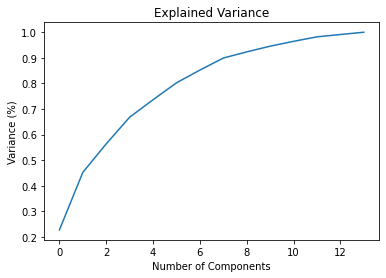

In [22]:
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features)

#Fitting the PCA algorithm with our Data
pca = PCA().fit(features_scaled)
#Plotting the Cumulative Summation of the Explained Variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)') #for each component
plt.title('Explained Variance')
plt.show()

### Data Analysis:

In this section, I test the performance of Gaussian Native Bayes, K-Nearest Neighbors, Decision Tree, and Random Forest and an Ensemble of the best performers. (Bagging, Boosting, vs. Stacking) ELO already gives a good idea of a team's likelihood of winning, where if the model simply picked the team with the highest ELO, it will often result in an accurate prediction most of the time. Focusing more on improving the F1-score of the model would reduce the number of false positives and negatives, and would be a better metric to evaluate the overall performance of the model.

In [48]:
from sklearn.metrics import make_scorer,f1_score
# features_pca = PCA(14).fit_transform(features_scaled)
x_train, x_test, y_train, y_test = train_test_split(featurep, labelp, test_size = 0.2)
# x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.1)

scorer = make_scorer(f1_score, pos_label=None, average='weighted')

In [24]:
from sklearn.naive_bayes import GaussianNB
pipelineNB= Pipeline([('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', GaussianNB(var_smoothing=.01))])
                   
pipelineNB.fit(x_train, y_train)
y_train_NB = pipelineNB.predict(x_train)
y_pred_NB = pipelineNB.predict(x_test)



In [25]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB)))

Train Accuracy score: 0.6589828897338403
Test Accuracy score: 0.6735741444866921
Test F1 score: 0.74790779621201


In [49]:
pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

pipelinerf.fit(x_train, y_train)
y_train_rf = pipelinerf.predict(x_train)
y_pred_rf = pipelinerf.predict(x_test)


In [50]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_rf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_rf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_rf)))

Train Accuracy score: 0.646245247148289
Test Accuracy score: 0.6461977186311787
Test F1 score: 0.7559984266421922


In [51]:
from sklearn.calibration import CalibratedClassifierCV
isotonicRFC = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinerf,cv = 5, method = "isotonic"))])

isotonicRFC.fit(x_train, y_train)
y_train_iso = isotonicRFC.predict(x_train)
y_pred_iso = isotonicRFC.predict(x_test)
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_iso)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_iso)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_iso)))



/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Train Accuracy score: 0.6657319391634982
Test Accuracy score: 0.6674904942965779
Test F1 score: 0.7433602347762289


The base Naive Bayes model performed the best out of the following models, with an accuracy of 65.5% on the test set, and a F1 score of .73, and the base RandomForestClassifier performed second best, with an an accuracy of 60.9% and an F1-score of .68.

In [29]:
# #Tuning GaussianNB Code from: https://stackoverflow.com/questions/39828535/how-to-tune-gaussiannb
# from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
# import numpy as np
# params_NB = {
#     'clf__priors': [None],
#     'clf__var_smoothing': np.logspace(0,-9, num=100)
# }

# gs_NB = GridSearchCV(estimator=pipelineNB, 
#                  param_grid=params_NB, 
#                  cv=10,   # use any cross validation technique 
#                  verbose=1, 
#                  scoring='f1') 
# gs_NB.fit(x_train, y_train)
# print(gs_NB.best_estimator_)
# y_train_NB_GS = gs_NB.predict(x_train)
# y_pred_NB_GS = gs_NB.predict(x_test)


In [30]:
# print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB_GS)))
# print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB_GS)))
# print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB_GS)))
# print('Average Decision Tree F1: {}'.format((cross_val_score(gs_NB, x_train, y_train, scoring=scorer)).mean()))

In [31]:
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np

# # Number of trees in random forest
# n_estimators = [int(x) for x in np.linspace(start = 0, stop = 2000, num = 11)]
# # Number of features to consider at every split
# max_features = ['auto', 'sqrt']
# # Maximum number of levels in tree
# max_depth = [int(x) for x in np.linspace(0, 100, num = 6)]
# max_depth.append(None)
# # Minimum number of samples required to split a node
# min_samples_split = [2, 5, 10]
# # Minimum number of samples required at each leaf node
# min_samples_leaf = [1, 2, 4]
# # Method of selecting samples for training each tree
# bootstrap = [True, False]
# # Create the random grid
# random_grid = {'clf__n_estimators': n_estimators,
#                'clf__max_features': max_features,
#                'clf__max_depth': max_depth,
#                'clf__min_samples_split': min_samples_split,
#                'clf__min_samples_leaf': min_samples_leaf,
#                'clf__bootstrap': bootstrap}


# # Use the random grid to search for best hyperparameters

# # Random search of parameters, using 2-fold cross validation, 
# # search across 100 different combinations, and use all available cores
# rfc_random = RandomizedSearchCV(estimator = pipelinerf, param_distributions = random_grid, n_iter = 100, cv = 2, verbose=2, n_jobs = -1)
# # Fit the random search model
# rfc_random.fit(x_train, y_train)
# y_pred_rfr_random = rfc_random.predict(x_test)
# print(metrics.accuracy_score(y_test, y_pred_rfr_random))


In [32]:
# X_train = features.iloc[:cutoffs[i], :]
#             X_test = features.iloc[cutoffs[i]:, :]
#             ml_train = win[:cutoffs[i]]
#             ml_test = win[cutoffs[i]:]
#             betting_results = betting_results.iloc[cutoffs[i]:, :]

bettingdf.head(20)

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB,avg_home_ml,avg_away_ml
0,2022-12-07,22200363,Final,1610612753,1610612746,2022,1610612753,116.0,0.421,0.903,...,15.2,41.2,90.6,0.3732,0.8156,0.2320,16.4,44.4,3.100000,1.363636
1,2022-12-07,22200364,Final,1610612751,1610612766,2022,1610612751,122.0,0.570,0.750,...,24.8,40.6,89.0,0.4358,0.6590,0.4092,21.2,40.8,1.200000,4.600000
2,2022-12-07,22200365,Final,1610612752,1610612737,2022,1610612752,113.0,0.446,0.917,...,20.2,44.6,93.4,0.4300,0.8266,0.2422,20.8,48.8,1.709220,2.050000
3,2022-12-07,22200366,Final,1610612761,1610612747,2022,1610612761,126.0,0.443,0.833,...,21.8,39.0,108.8,0.5270,0.7726,0.4578,28.6,38.6,1.120048,6.250000
4,2022-12-07,22200367,Final,1610612741,1610612764,2022,1610612741,115.0,0.500,0.882,...,23.4,48.2,85.2,0.4014,0.7738,0.3132,18.4,41.0,1.490196,2.600000
5,2022-12-07,22200368,Final,1610612763,1610612760,2022,1610612763,123.0,0.511,0.813,...,26.0,47.6,89.0,0.4102,0.7336,0.4230,21.2,40.2,1.270270,3.600000
6,2022-12-07,22200369,Final,1610612749,1610612758,2022,1610612749,126.0,0.479,0.833,...,25.2,44.4,109.8,0.5018,0.7778,0.4550,30.6,44.4,1.370370,3.000000
7,2022-12-07,22200370,Final,1610612750,1610612754,2022,1610612750,121.0,0.473,0.926,...,28.6,39.2,93.0,0.4526,0.7954,0.3902,25.4,45.4,1.476190,2.650000
8,2022-12-07,22200371,Final,1610612740,1610612765,2022,1610612740,104.0,0.459,0.783,...,22.2,44.4,85.8,0.3876,0.7654,0.3506,19.8,47.6,1.178571,5.000000
9,2022-12-07,22200372,Final,1610612762,1610612744,2022,1610612762,124.0,0.535,0.810,...,21.0,43.0,96.6,0.4536,0.7444,0.3328,20.2,44.8,1.440529,2.700000


In [33]:


def kelly(prob_win, payout_perc):
    return (prob_win * (payout_perc-1) - (1 - prob_win)) / (payout_perc-1)

def prob_edge(prob_win, payout_perc):
    return abs(prob_win - (1/((payout_perc-1)+1)))

def expected_value(wager, prob_win, payout_perc):
    return (wager * (payout_perc-1) * prob_win) - (wager * (1-prob_win))

def pickKellyBet(prob_win,homePayout, awayPayout):
    kellyHome = kelly(prob_win,homePayout)
    kellyAway = kelly(1-prob_win,awayPayout)
    evH = expected_value(kellyHome,prob_win,homePayout)
    evA = expected_value(kellyAway,1-prob_win,awayPayout)
    if(evA <= 0 and evH <= 0):
        return 0.5
    if evH > evA:
        return 1
    else:
        return 0

maxProfit = []
meanwinRate = []

def simulate_bets(df):
    startBankroll = 47
    df = df.reset_index()
    df.loc[0, 'bankroll_i'] = startBankroll
    for idx in df.index:
        if np.isnan(df.loc[idx, 'bankroll_i']):
            df.loc[idx, 'bankroll_i'] = df.loc[idx-1, 'bankroll_n']
        
        payout = np.nan
        bet = df.loc[idx,'bets']
        # print(bet)
        probs = df.loc[idx, 'model_probability']

        if (bet == 1):
            payout = df.loc[idx,'avg_home_ml']
        else:
            payout = df.loc[idx,'avg_away_ml']
            probs = 1 - probs

        
        
        # print(probs)
        # print(payout)

        df.loc[idx, 'bet_size'] = df.loc[idx, 'bankroll_i'] * (.2 * kelly(probs,payout))
        if df.loc[idx, 'bet_won'] == 1:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i'] + (payout-1)*df.loc[idx, 'bet_size']
        elif df.loc[idx, 'bet_won'] == 0:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i'] - df.loc[idx, 'bet_size']
        else:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i']
            
    plt.style.use('fivethirtyeight')

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.plot(range(df.shape[0]), df['bankroll_i'], linewidth=1.5)            
    plt.show()
    min_balance = df['bankroll_n'].min()
    max_balance = df['bankroll_n'].max()
    final_balance = df['bankroll_n'].iloc[-1]
    win_pct = df.loc[df['bet_won'] != 0.5, 'bet_won'].mean()
    maxProfit.append((max_balance-startBankroll)/startBankroll)
    meanwinRate.append(round(win_pct, 4) * 100)
    print("min balance:", min_balance,
         "\nmax balance:", max_balance,
         "\nfinal balance:", final_balance,
         "\nwin percentage", round(win_pct, 4) * 100,
         "\n MaxProfit Mean", sum(maxProfit) / len(maxProfit),
         "\n Current Mean Winrate", sum(meanwinRate) / len(meanwinRate))
    return df



In [34]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml']].copy()
# print(betting_results.iloc[:cutoffs[6], :])
# print(bettingdf.shape)
# print(features1.shape)
def train_model(features=features1):
    
    win = bettingdf['HOME_TEAM_WINS']
    
    result_dfs = []
    
    for i in range(len(cutoffs)):
        betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml']].copy()
        if i == len(cutoffs) - 1:
            X_train = features.iloc[cutoffs[i]:, :]
            X_test = features.iloc[:cutoffs[i], :]
            ml_train = win[cutoffs[i]:]
            ml_test = win[:cutoffs[i]]
            betting_results = betting_results.iloc[:cutoffs[i], :]
            print(X_test.shape)
        else:
            X_train = features.iloc[cutoffs[i]:, :]
            X_test = features.iloc[cutoffs[i+1]:cutoffs[i], :]
            ml_train = win[cutoffs[i]:]
            ml_test = win[cutoffs[i+1]:cutoffs[i]]
            betting_results = betting_results.iloc[cutoffs[i+1]:cutoffs[i]]
            
            print(X_test.shape)
        
        
        pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

        pipeline = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinerf,cv = 5, method = "isotonic"))])

        # pipeline = Pipeline(steps=[('scaler', RobustScaler()),
        #            ('pca', PCA(n_components=14)),
        #            ('clf', KNeighborsClassifier(n_neighbors=3))])

        pipeline.fit(X_train, ml_train)
        preds = pipeline.predict(X_test)
        probs = pipeline.predict_proba(X_test)

        train_accuracy = pipeline.score(X_train, ml_train)
        test_accuracy = pipeline.score(X_test, ml_test)
        print("season {}".format(i+2017))
        print("train_accuracy:", train_accuracy, "test_accuracy:", test_accuracy)

                
        if i == len(cutoffs) - 1:
            betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml','HOME_TEAM_WINS']].iloc[:cutoffs[i], :]
            
        else:
            betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml','HOME_TEAM_WINS']].iloc[cutoffs[i+1]:cutoffs[i], :]
            
        betting_results['model_pred'] = preds
        betting_results['model_probability'] = probs[:, 1]
        betting_results['bets'] = betting_results.apply(lambda x: pickKellyBet(x.model_probability, x.avg_home_ml, x.avg_away_ml), axis=1)
        betting_results['bet_won'] = (betting_results['HOME_TEAM_WINS'] == betting_results['bets']).astype(int)

        betting_results['bankroll_i'] = np.nan
        betting_results['bankroll_n'] = np.nan
        betting_results['bet_size'] = np.nan
        

        select_bets = betting_results.loc[(((betting_results['model_probability'] > 0.56)
                                          |(betting_results['model_probability'] < 0.44)) & (betting_results['bets'] != 0.5))]
        ranges = []
        win_percentages = []
        for i in range(1, 20):
            for j in range(1, 20):
                select_bets = betting_results.loc[(betting_results['model_probability'] > 0.5 + i/100)
                                          | (betting_results['model_probability'] < 0.5 - j/100)]
        
        win_pct = select_bets['bet_won'].mean()
        ranges.append((0.5-j/100, 0.5+i/100))
        win_percentages.append(win_pct)
        
        prob_ranges = pd.DataFrame({'probability_range':ranges, 'win_percentage':win_percentages})
        print(prob_ranges)
        
        
        results = simulate_bets(select_bets)
        result_dfs.append(results)
    return result_dfs

In [35]:
# res = train_model(features1)

In [56]:
# import argparse

import requests


# # Obtain the api key that was passed in from the command line
# parser = argparse.ArgumentParser(description='Sample V4')
# parser.add_argument('--api-key', type=str, default='')
# args = parser.parse_args()


# An api key is emailed to you when you sign up to a plan
# Get a free API key at https://api.the-odds-api.com/
API_KEY ='fd9ad2bd869c7d9230e286b9533bff38'

SPORT = 'basketball_nba' # use the sport_key from the /sports endpoint below, or use 'upcoming' to see the next 8 games across all sports

REGIONS = 'us' # uk | us | eu | au. Multiple can be specified if comma delimited

MARKETS = 'h2h' # h2h | spreads | totals. Multiple can be specified if comma delimited

ODDS_FORMAT = 'decimal' # decimal | american

DATE_FORMAT = 'iso' # iso | unix

BOOKMAKERS= ['bovada']

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # 
#
# First get a list of in-season sports
#   The sport 'key' from the response can be used to get odds in the next request
#
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # 

# sports_response = requests.get('https://api.the-odds-api.com/v4/sports', params={
#     'api_key': API_KEY
# })


# if sports_response.status_code != 200:
#     print(f'Failed to get sports: status_code {sports_response.status_code}, response body {sports_response.text}')

# else:
#     print('List of in season sports:', sports_response.json())



# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # 
#
# Now get a list of live & upcoming games for the sport you want, along with odds for different bookmakers
# This will deduct from the usage quota
# The usage quota cost = [number of markets specified] x [number of regions specified]
# For examples of usage quota costs, see https://the-odds-api.com/liveapi/guides/v4/#usage-quota-costs
#
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # 

odds_response = requests.get(f'https://api.the-odds-api.com/v4/sports/{SPORT}/odds', params={
    'api_key': API_KEY,
    'regions': REGIONS,
    'markets': MARKETS,
    'oddsFormat': ODDS_FORMAT,
    'dateFormat': DATE_FORMAT,
    'bookmakers': BOOKMAKERS
})

if odds_response.status_code != 200:
    print(f'Failed to get odds: status_code {odds_response.status_code}, response body {odds_response.text}')

else:
    odds_json = odds_response.json()
    print('Number of events:', len(odds_json))
    print(odds_json)

    # Check the usage quota
    print('Remaining requests', odds_response.headers['x-requests-remaining'])
    print('Used requests', odds_response.headers['x-requests-used'])

Number of events: 7
[{'id': 'ebb21e6982eae11aadedce4bf974ec5d', 'sport_key': 'basketball_nba', 'sport_title': 'NBA', 'commence_time': '2022-12-17T21:10:00Z', 'home_team': 'Los Angeles Clippers', 'away_team': 'Washington Wizards', 'bookmakers': [{'key': 'bovada', 'title': 'Bovada', 'last_update': '2022-12-17T18:36:50Z', 'markets': [{'key': 'h2h', 'outcomes': [{'name': 'Los Angeles Clippers', 'price': 1.37}, {'name': 'Washington Wizards', 'price': 3.2}]}]}]}, {'id': 'c3bff2f648685c6b4658302e0c5c4263', 'sport_key': 'basketball_nba', 'sport_title': 'NBA', 'commence_time': '2022-12-17T22:10:00Z', 'home_team': 'San Antonio Spurs', 'away_team': 'Miami Heat', 'bookmakers': [{'key': 'bovada', 'title': 'Bovada', 'last_update': '2022-12-17T18:36:50Z', 'markets': [{'key': 'h2h', 'outcomes': [{'name': 'Miami Heat', 'price': 1.3}, {'name': 'San Antonio Spurs', 'price': 3.65}]}]}]}, {'id': '4a779849bdd1fcd615c144a57ba5e70e', 'sport_key': 'basketball_nba', 'sport_title': 'NBA', 'commence_time': '2022-

In [53]:
def flatten_json(nested_json, exclude=['']):
    """Flatten json object with nested keys into a single level.
        Args:
            nested_json: A nested json object.
            exclude: Keys to exclude from output.
        Returns:
            The flattened json object if successful, None otherwise.
    """
    out = {}

    def flatten(x, name='', exclude=exclude):
        if type(x) is dict:
            for a in x:
                if a not in exclude: flatten(x[a], name + a + '_')
        elif type(x) is list:
            i = 0
            for a in x:
                flatten(a, name + str(i) + '_')
                i += 1
        else:
            out[name[:-1]] = x

    flatten(nested_json)
    return out

In [57]:
odds_json_copy = odds_json
fullNameMap = dict(zip(teams.CITY + ' ' + teams.NICKNAME , teams.TEAM_ID))
df = pd.json_normalize(odds_json_copy)
dfx = pd.DataFrame([flatten_json(x) for x in df['bookmakers']])
dfx = dfx.dropna()
dfx['0_markets_0_outcomes_0_name'] = dfx['0_markets_0_outcomes_0_name'].replace(fullNameMap)
dfx['0_markets_0_outcomes_1_name'] = dfx['0_markets_0_outcomes_1_name'].replace(fullNameMap)
dfx.head(10)

,0_key,0_title,0_last_update,0_markets_0_key,0_markets_0_outcomes_0_name,0_markets_0_outcomes_0_price,0_markets_0_outcomes_1_name,0_markets_0_outcomes_1_price
0,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612746,1.37,1610612764,3.20
1,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612748,1.30,1610612759,3.65
2,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612739,1.29,1610612742,3.75
3,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612745,2.50,1610612757,1.57
4,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612763,1.28,1610612760,3.80
5,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612749,1.59,1610612762,2.45
6,bovada,Bovada,2022-12-17T18:36:50Z,h2h,1610612740,2.30,1610612756,1.67


In [58]:
#This code uses an NBA_API endpoint to obtain today's games and predicts the result of them. Example modified from NBA_API docs: https://github.com/swar/nba_api/blob/master/docs/examples/LiveData.ipynb

# Query nba.live.endpoints.scoreboard and  list games in localTimeZone
from datetime import datetime, timezone
from dateutil import parser
from nba_api.live.nba.endpoints import scoreboard
bankroll = 172.65

f = "{gameId}:  {awayTeam} vs. {homeTeam} @ {gameTimeLTZ}" 

board = scoreboard.ScoreBoard()
print("ScoreBoardDate: " + board.score_board_date)
games = board.games.get_dict()
for game in games:
    gameTimeLTZ = parser.parse(game["gameTimeUTC"]).replace(tzinfo=timezone.utc).astimezone(tz=None)
    print(f.format(gameId=game['gameId'], awayTeam=game['awayTeam']['teamName'], homeTeam=game['homeTeam']['teamName'], gameTimeLTZ=gameTimeLTZ))
    homeTeamID = game['homeTeam']['teamId']
    awayTeamID = game['awayTeam']['teamId']
    print(homeTeamID)
    homeTeamPerformance = recentTeamPerformance[homeTeamID]
    awayTeamPerformance = recentTeamPerformance[awayTeamID]
    inputList = [current_elo[homeTeamID],current_elo[awayTeamID]]
    isoPred = isotonicRFC.predict([inputList + homeTeamPerformance + awayTeamPerformance])
    isoProb = isotonicRFC.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])

    prob_win = isoProb[0][1]
    print("Away Elo: " + str(current_elo[awayTeamID]) + " Home Elo: " + str(current_elo[homeTeamID]))
    print('ISORandom Forest Predict: ' + str(isoPred))
    print('ISORandom Forest Probs: ' +  str(isoProb))
    

    currRow = dfx.loc[(dfx['0_markets_0_outcomes_0_name'] == homeTeamID) | (dfx['0_markets_0_outcomes_0_name'] == awayTeamID)]
    if currRow.empty:
        continue
    currID = currRow.values[0][4]
   
    if (currID == awayTeamID):
        awayPayout = currRow.values[0][5]
        homePayout = currRow.values[0][7]
    else:
        awayPayout = currRow.values[0][7]
        homePayout = currRow.values[0][5]

    kellyHome = kelly(prob_win,homePayout)
    kellyAway = kelly(1-prob_win,awayPayout)
    probEHome = prob_edge(prob_win,homePayout)
    probEAway = prob_edge(1-prob_win,awayPayout)
    evH = expected_value(kellyHome,prob_win,homePayout)
    evA = expected_value(kellyAway,1-prob_win,awayPayout)
    evHper = expected_value(100,prob_win,homePayout)
    evAper = expected_value(100,1-prob_win,awayPayout)
    print("Away Odds: " + str(awayPayout) + " Home Odds: " + str(homePayout))
    print("Away EV: " + str(evA) + " Home EV: " + str(evH))
    print("Away EV%: " + str(evAper) + " Home EV%: " + str(evHper))
    print("Kelly Away: " + str(kellyAway) + " Kelly Home: " + str(kellyHome))
    print("Kelly Bet Away: " + str(.2 * kellyAway * bankroll) + " Kelly Bet Home: " + str(.2 * kellyHome * bankroll))
    print("Away Prob Edge: " + str(probEHome) + " Home Prob Edge: " + str(probEAway))
    if(prob_win > 0.56 or prob_win <0.44):
        print('Bot Bets on this Game if Positive EV.')
    
    # print('Random Forest Predict: ' + str(pipelinerf.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
    # print('Random Forest Probs: ' +  str(pipelinerf.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('\n')

ScoreBoardDate: 2022-12-17
0022200438:  Wizards vs. Clippers @ 2022-12-17 16:00:00-05:00
1610612746
Away Elo: 1403.5133869213028 Home Elo: 1496.9710252173172
ISORandom Forest Predict: [1]
ISORandom Forest Probs: [[0.25048266 0.74951734]]
Away Odds: 3.2 Home Odds: 1.37
Away EV: 0.01790207978125022 Home EV: 0.0019468067889216976
Away EV%: -19.845547490243362 Home EV%: 2.683875019260455
Kelly Away: -0.09020703404656075 Kelly Home: 0.07253716268271487
Kelly Bet Away: -3.114848885627743 Kelly Bet Home: 2.504708227434145
Away Prob Edge: 0.01959032860774046 Home Prob Edge: 0.06201733590701053
Bot Bets on this Game if Positive EV.


0022200439:  Heat vs. Spurs @ 2022-12-17 17:00:00-05:00
1610612759
Away Elo: 1563.8561150873757 Home Elo: 1333.263641658514
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.62047793 0.37952207]]
Away Odds: 1.3 Home Odds: 3.65
Away EV: 0.12465105709926429 Home EV: 0.05600824054065158
Away EV%: -19.33786884063994 Home EV%: 38.52555482179676
Kelly Away: -0.64

Predicting Winners of NBA Games

The project’s goal is to accurately predict whether or not an NBA team wins a given matchup. After researching, it seems the best way to approach this problem is to treat it as a classification problem, since NBA games do not end as a draw, which allows for a binary result.
In order to accomplish this, I have to be able to collect sufficient data, create features from that data that are correlated with the winning potential of a team, and use a tuned model in order to get the best accuracy score. Currently, I have a RandomForest classifier model, and I plan on testing other classifiers like Logistic Regression, K-Nearest Neighbors, and SVM up against it, to see which model will perform the best. After looking at the models, I plan on testing different hyperparameter tuning methods like Grid Search, Random Search and Bayesian Optimization to see which one optimizes the models and results in the most accurate score. I plan on documenting my tests with various graphs and metrics to compare the performance of each model.

Status/Description:

To get the data, I used a data scraping script I found online and used it to scrape game and player data from NBA.com, which scraped game data from the 2003 NBA season all the way to Today’s NBA Games. The scraper resulted in multiple csv files, but the ones I would be interested in would be games.csv, which contains every game’s team stats and box score for the past 20 years, and games_details.csv which provides player stats for each game, based on game ID. Teams.csv and Player.csv contain data on which teamID and playerID correspond with which team and player.
Through research, I found ELO to be one of the best features to use in determining which team wins, since it is a mathematical relationship between the strength of the teams (Beating tougher opponents raises ELO higher), and is reset each season, giving an edge over season trackers like rankings. I used code to calculate the ELO levels of each world cup team to calculate the historical ELO scores of each NBA team before each NBA game in the past 20 years, and updated the scores after each game as well. For each game, I also averaged the teams’ performance in the past 5 games for each game in order to better account for recent team performance in the context of the matchup, and to somewhat account for star player injuries. I currently have two features, the ELOs of the teams and the recent performances of each team.
I currently have a RandomForestClassifier, which gives me an accuracy of 62%, which is pretty good. From what I researched, the best models that predict NBA outcomes are around the 70% mark. I’d like to see how much tuning the model would improve my output by, and whether or not other classification models would perform better. Since I am only using free, publicly available data, I wonder how close I can get the model to 70%, compared to the models that use paid data.

Status:

As for what remains to be done, I would like to include player stats in my model, which would help differentiate what players make a specific team good besides aggregated scores like ELO, which approximate the strength of an entire team. When players get injured for a long period of time (~5+ games), their elo seems to take a hit before the model can determine that the team is weaker. If I include the player stats, hopefully the model can quickly determine the decline of a team due to injury. I would also like to explore basketball metrics like Team offensive and defensive rating, and Player Efficiency Ratings to see if they make a difference in how the model performs. I also wonder if having betting odds would change the performance, as they do reflect well on the probability of a specific match up, however I am not completely sure if it would be a good addition to the ELO feature I have. As stated before, the current model does need to be tuned, and I also plan on comparing the performance of different classification models. I also plan on seeing how standardizing my data would affect the accuracy score.

Code:

My code takes in the data, creates features within the dataframe, and uses it in the model to train it. When my project is complete, most of the code should be the same, however there would be more cells related to the analysis of the models at the bottom, and potentially new cells related to feature creation in the middle.
